## WeGo Data Introduction

In [1]:
import pandas as pd
import numpy as np

In [2]:
wego = pd.read_csv("../Headway Data, 8-1-2023 to 9-30-2023.csv")
wego.head()

,CALENDAR_ID,SERVICE_ABBR,ADHERENCE_ID,DATE,ROUTE_ABBR,BLOCK_ABBR,OPERATOR,TRIP_ID,OVERLOAD_ID,ROUTE_DIRECTION_NAME,...,ACTUAL_HDWY,HDWY_DEV,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,STOP_CANCELLED,PREV_SCHED_STOP_CANCELLED,IS_RELIEF,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES
0,120230801,1,99457890,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,6.500000,NaN
1,120230801,1,99457891,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
2,120230801,1,99457892,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,0.000000,NaN
3,120230801,1,99457893,2023-08-01,22,2200,1040,345104,0,TO DOWNTOWN,...,NaN,NaN,0,0,1,0,NaN,0,0.000000,NaN
4,120230801,1,99457894,2023-08-01,22,2200,1040,345105,0,FROM DOWNTOWN,...,NaN,NaN,0,0,1,0,0.0,0,12.866666,5.0


In [3]:
wego.columns

Index(['CALENDAR_ID', 'SERVICE_ABBR', 'ADHERENCE_ID', 'DATE', 'ROUTE_ABBR',
       'BLOCK_ABBR', 'OPERATOR', 'TRIP_ID', 'OVERLOAD_ID',
       'ROUTE_DIRECTION_NAME', 'TIME_POINT_ABBR', 'ROUTE_STOP_SEQUENCE',
       'TRIP_EDGE', 'LATITUDE', 'LONGITUDE', 'SCHEDULED_TIME',
       'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
       'SCHEDULED_HDWY', 'ACTUAL_HDWY', 'HDWY_DEV', 'ADJUSTED_EARLY_COUNT',
       'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT', 'STOP_CANCELLED',
       'PREV_SCHED_STOP_CANCELLED', 'IS_RELIEF', 'DWELL_IN_MINS',
       'SCHEDULED_LAYOVER_MINUTES'],
      dtype='object')

In the data, the bus route can be identified by its ROUTE_ABBR value.  
**3:** West End  
**7:** Hillsboro  
**22:** Bordeaux  
**23:** Dickerson Pike  
**50:** Charlotte Pike  
**52:** Nolensville Pike  
**55:** Murfreesboro Pike  
**56:** Gallatin Pike

In [4]:
wego['ROUTE_ABBR'].value_counts().sort_index()

ROUTE_ABBR
3     47162
7     18026
22    25959
23    42108
50    43291
52    51819
55    61944
56    60020
Name: count, dtype: int64

The trip can be identified by the DATE/CALENDAR_ID plus the TRIP_ID.  
**Warning:** The TRIP_ID refers to the route and time but will be used across multiple days.

The data contains multiple **time points** for each trip. There are more stops along the route than time points, but the time points are the points with specific scheduled times the bus operators must adhere to.

The first stop of a trip has a TRIP_EDGE of 1, the last has a TRIP_EDGE of 2, and the intermediate stops are TRIP_EDGE 0. 

Here is the first trip in the dataset. It was a Bordeaux route (Route 22), scheduled to start at 4:42:00 and end at 5:10:00.

In [5]:
wego[['DATE', 'CALENDAR_ID', 'TRIP_ID', 'ROUTE_ABBR', 'TIME_POINT_ABBR', 'TRIP_EDGE', 'SCHEDULED_TIME']].loc[:3]

,DATE,CALENDAR_ID,TRIP_ID,ROUTE_ABBR,TIME_POINT_ABBR,TRIP_EDGE,SCHEDULED_TIME
0,2023-08-01,120230801,345104,22,MHSP,1,2023-08-01 04:42:00
1,2023-08-01,120230801,345104,22,ELIZ,0,2023-08-01 04:46:00
2,2023-08-01,120230801,345104,22,CV23,0,2023-08-01 04:54:00
3,2023-08-01,120230801,345104,22,MCC5_10,2,2023-08-01 05:10:00


Note that the same TRIP_ID appears on the following day.

In [6]:
(
    wego
    .loc[wego['DATE'].astype(str).isin(['2023-08-01', '2023-08-02'])]
    .loc[wego['TRIP_ID'] == 345104]
    [['DATE', 'ROUTE_ABBR', 'TRIP_ID', 'TIME_POINT_ABBR', 'TRIP_EDGE', 'ROUTE_DIRECTION_NAME', 'SCHEDULED_TIME', 'ROUTE_STOP_SEQUENCE']]
)

,DATE,ROUTE_ABBR,TRIP_ID,TIME_POINT_ABBR,TRIP_EDGE,ROUTE_DIRECTION_NAME,SCHEDULED_TIME,ROUTE_STOP_SEQUENCE
0,2023-08-01,22,345104,MHSP,1,TO DOWNTOWN,2023-08-01 04:42:00,14.0
1,2023-08-01,22,345104,ELIZ,0,TO DOWNTOWN,2023-08-01 04:46:00,10.0
2,2023-08-01,22,345104,CV23,0,TO DOWNTOWN,2023-08-01 04:54:00,5.0
3,2023-08-01,22,345104,MCC5_10,2,TO DOWNTOWN,2023-08-01 05:10:00,1.0
6461,2023-08-02,22,345104,MHSP,1,TO DOWNTOWN,2023-08-02 04:42:00,14.0
6462,2023-08-02,22,345104,ELIZ,0,TO DOWNTOWN,2023-08-02 04:46:00,10.0
6463,2023-08-02,22,345104,CV23,0,TO DOWNTOWN,2023-08-02 04:54:00,5.0
6464,2023-08-02,22,345104,MCC5_10,2,TO DOWNTOWN,2023-08-02 05:10:00,1.0


**Adherence** refers to the difference between scheduled time and the actual time that the bus departs from a stop.

A negative value for ADHERENCE indicates that the bus is late, and a positive indicates that the bus is early.

Generally, an adherence value less than -6 is considered late, and greater than 1 is considered early, but there are some exceptions. For example, a positive adherence for the end of a trip (TRIP_EDGE 2) is not considered early, since it is not a problem if a bus ends its trip early as long as it didn't pass other timepoints early along the way. You can check whether a trip was considered on-time, early, or late using the ADJUSTED_EARLY_COUNT, ADJUSTED_LATE_COUNT, and ADJUSTED_ONTIME_COUNT columns.

Here is an example of a trip where all time points would be considered to be on time. Notice that at the end of the trip, the bus was more than 6 minutes early, but was still counted as on-time since this was a trip edge of 2.

In [7]:
(
    wego
    [[
        'DATE', 'CALENDAR_ID', 'TRIP_ID', 'ROUTE_ABBR',
        'TIME_POINT_ABBR', 'TRIP_EDGE',
        'SCHEDULED_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
        'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT'
    ]]
    .loc[:3]
)

,DATE,CALENDAR_ID,TRIP_ID,ROUTE_ABBR,TIME_POINT_ABBR,TRIP_EDGE,SCHEDULED_TIME,ACTUAL_DEPARTURE_TIME,ADHERENCE,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT
0,2023-08-01,120230801,345104,22,MHSP,1,2023-08-01 04:42:00,2023-08-01 04:44:08,-2.133333,0,0,1
1,2023-08-01,120230801,345104,22,ELIZ,0,2023-08-01 04:46:00,2023-08-01 04:48:27,-2.450000,0,0,1
2,2023-08-01,120230801,345104,22,CV23,0,2023-08-01 04:54:00,2023-08-01 04:54:56,-0.933333,0,0,1
3,2023-08-01,120230801,345104,22,MCC5_10,2,2023-08-01 05:10:00,2023-08-01 05:03:43,6.283333,0,0,1


And one that has one late stop.

In [8]:
(
    wego
    [[
        'DATE', 'CALENDAR_ID', 'TRIP_ID', 'ROUTE_ABBR',
        'TIME_POINT_ABBR', 'TRIP_EDGE',
        'SCHEDULED_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
        'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT'
    ]]
    .loc[77:79]
)

,DATE,CALENDAR_ID,TRIP_ID,ROUTE_ABBR,TIME_POINT_ABBR,TRIP_EDGE,SCHEDULED_TIME,ACTUAL_DEPARTURE_TIME,ADHERENCE,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT
77,2023-08-01,120230801,345127,22,MHSP,1,2023-08-01 17:05:00,2023-08-01 17:08:21,-3.350000,0,0,1
78,2023-08-01,120230801,345127,22,CV23,0,2023-08-01 17:14:00,2023-08-01 17:20:10,-6.166666,0,1,0
79,2023-08-01,120230801,345127,22,MCC5_10,2,2023-08-01 17:30:00,2023-08-01 17:30:23,-0.383333,0,0,1


And one which was early.

In [9]:
(
    wego
    [[
        'DATE', 'CALENDAR_ID', 'TRIP_ID', 'ROUTE_ABBR',
        'TIME_POINT_ABBR', 'TRIP_EDGE',
        'SCHEDULED_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
        'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT'
    ]]
    .loc[11:13]
)

,DATE,CALENDAR_ID,TRIP_ID,ROUTE_ABBR,TIME_POINT_ABBR,TRIP_EDGE,SCHEDULED_TIME,ACTUAL_DEPARTURE_TIME,ADHERENCE,ADJUSTED_EARLY_COUNT,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT
11,2023-08-01,120230801,345107,22,MCC5_10,1,2023-08-01 06:15:00,2023-08-01 06:16:19,-1.316666,0,0,1
12,2023-08-01,120230801,345107,22,CV23,0,2023-08-01 06:25:00,2023-08-01 06:23:30,1.500000,1,0,0
13,2023-08-01,120230801,345107,22,MHSP,2,2023-08-01 06:35:00,2023-08-01 06:30:59,4.016666,0,0,1


**Headway** is the amount of time between a bus and the prior bus at the same stop. In the dataset, the amount of headway scheduled is contained in the SCHEDULED_HDWY column and indicates the difference between the scheduled time for a particular stop and the scheduled time for the previous bus on that same stop.

This dataset contains a column HDWY_DEV, which shows the amount of deviation from the scheduled headway. **Bunching** occurs when there is shorter headway than scheduled, which would appear as a negative HDWY_DEV value. **Gapping** is when there is more headway than scheduled and appears as a positive value in the HDWY_DEV column. Note that you can calculate headway deviation percentage as HDWY_DEV/SCHEDULED_HDWY. 

The generally accepted range of headway deviation is 50% to 150% of the scheduled headway, so if scheduled headway is 10 minutes, a headway deviation of up to 5 minutes would be acceptable (but not ideal).

In [10]:
(
    wego
    .loc[wego['ROUTE_ABBR'] == 22]
    .loc[wego['ROUTE_DIRECTION_NAME'] == 'TO DOWNTOWN']
    .loc[wego['TIME_POINT_ABBR'] == 'CV23']
    [['DATE', 'TRIP_ID', 'TIME_POINT_ABBR','ROUTE_DIRECTION_NAME', 'TRIP_EDGE', 
      'SCHEDULED_TIME', 'SCHEDULED_HDWY',
      'ACTUAL_DEPARTURE_TIME', 'ACTUAL_HDWY', 'HDWY_DEV'
     ]]
    .sort_values(['DATE', 'SCHEDULED_TIME'])
    .iloc[:5]
)

,DATE,TRIP_ID,TIME_POINT_ABBR,ROUTE_DIRECTION_NAME,TRIP_EDGE,SCHEDULED_TIME,SCHEDULED_HDWY,ACTUAL_DEPARTURE_TIME,ACTUAL_HDWY,HDWY_DEV
2,2023-08-01,345104,CV23,TO DOWNTOWN,0,2023-08-01 04:54:00,NaN,2023-08-01 04:54:56,NaN,NaN
126,2023-08-01,345213,CV23,TO DOWNTOWN,0,2023-08-01 05:19:00,25.0,2023-08-01 05:18:59,24.050000,-0.950000
402,2023-08-01,345405,CV23,TO DOWNTOWN,0,2023-08-01 05:39:00,20.0,2023-08-01 05:39:40,20.683333,0.683333
9,2023-08-01,345106,CV23,TO DOWNTOWN,0,2023-08-01 05:54:00,15.0,2023-08-01 05:54:11,14.516666,-0.483334
316,2023-08-01,345377,CV23,TO DOWNTOWN,0,2023-08-01 06:09:00,15.0,2023-08-01 06:10:01,15.833333,0.833333


Two other columns that you've been asked to explore are the DWELL_IN_MINS column and SCHEDULED_LAYOVER_MINUTES, which shows the difference between actual arrival and actual departure time at a time point and the time a bus was scheduled to arrive at the time point and when it is scheduled to leave at the beginning of a trip.

Here, we can see the end of the first trip in the dataset and the beginning of the next trip, which goes in the opposite direction.

In [11]:
wego.loc[3:4, ['DATE', 'TRIP_ID', 'TRIP_EDGE', 'TIME_POINT_ABBR',
               'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'DWELL_IN_MINS', 'SCHEDULED_LAYOVER_MINUTES']]

,DATE,TRIP_ID,TRIP_EDGE,TIME_POINT_ABBR,ACTUAL_ARRIVAL_TIME,ACTUAL_DEPARTURE_TIME,DWELL_IN_MINS,SCHEDULED_LAYOVER_MINUTES
3,2023-08-01,345104,2,MCC5_10,2023-08-01 05:03:43,2023-08-01 05:03:43,0.000000,NaN
4,2023-08-01,345105,1,MCC5_10,2023-08-01 05:03:43,2023-08-01 05:16:35,12.866666,5.0


## (1) What is the overall on-time performance, and what do the overall distribution of adherence look like?

In [20]:
workingtable = wego.copy()

ontime_count = workingtable['ADJUSTED_ONTIME_COUNT'].mean()
ontime_count

0.7708411236295025

In [13]:
# workingtable['ADHERENCE']

In [14]:
# workingtable[['ADHERENCE', 'ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT']]

In [15]:
# total_count = workingtable['ADHERENCE'].notnull().sum()  # Count non-null ADHERENCE values
# ontime_count = workingtable['ADJUSTED_ONTIME_COUNT'].sum()  # Sum of on-time stops
# ontime_perc = (ontime_count / total_count) * 100

# workingtable.head()

In [16]:
# print(f"Overall On-Time Performance: {ontime_perc:.2f}%")

In [17]:
# print(f"On-Time Stops: {ontime_count} \n Total Stops: {total_count}")

In [18]:
# conditions = [
    
#     workingtable['ADHERENCE'] <= -6,
#     workingtable['ADHERENCE'] >= -6,
#     workingtable['ADHERENCE'] == 2,
#     workingtable['ADHERENCE'] >= 1
# ]

# choices = ['Late', 'On Time', 'Last Stop', 'Early']

# workingtable['ON_TIME'] = np.select(conditions , choices)

# workingtable[['ON_TIME', 'ADHERENCE']]

In [21]:
# Cell 5 Q1  (Probably the only cell we actually needed)

# Grouped to the stop type

trip_edge_counts = workingtable.groupby('TRIP_EDGE').agg({
    'ADJUSTED_EARLY_COUNT': 'sum',
    'ADJUSTED_LATE_COUNT': 'sum',
    'ADJUSTED_ONTIME_COUNT': 'sum'
}).reset_index()

# Keep It Simple Stupid

trip_edge_counts = trip_edge_counts.rename(columns={
    'ADJUSTED_EARLY_COUNT': 'EARLY',
    'ADJUSTED_LATE_COUNT': 'LATE',
    'ADJUSTED_ONTIME_COUNT': 'ONTIME'
})

# Labels for reading stuff easy

trip_edge_counts['TRIP_EDGE'] = trip_edge_counts['TRIP_EDGE'].map({
    0: 'Middle Run',
    1: 'First Stop',
    2: 'Last Stop'
})

# Ordered for mah viewing pleasure

trip_edge_counts = trip_edge_counts[['TRIP_EDGE', 'EARLY', 'LATE', 'ONTIME']]

# hava looky see

trip_edge_counts

,TRIP_EDGE,EARLY,LATE,ONTIME
0,Middle Run,7952,40423,159497
1,First Stop,1081,6210,58421
2,Last Stop,742,12405,52130


In [ ]:
# Calculate overall on-time performance
# total_count = workingtable['ADHERENCE'].notnull().sum()  # Count non-null ADHERENCE values
# ontime_count = workingtable['ON_TIME'].sum()  # Sum of on-time stops
# ontime_perc = (ontime_count / total_count) * 100

# workingtable.head()

In [ ]:
print(f"Overall On-Time Performance: {ontime_perc:.2f}%")

In [ ]:
print(f"On-Time Stops: {ontime_count} \n Total Stops: {total_count}")

In [ ]:
# # Create a copy of the DataFrame
# workingtable = wego.copy()

# # Add a column for on-time status (1 for on-time, 0 for not on-time)
# # On-time is defined as ADHERENCE between -5 and 0 minutes (inclusive)
# workingtable['ON_TIME'] = workingtable['ADHERENCE'].apply(
#     lambda x: 1 if pd.notnull(x) and -5 <= x or x >= 5 else 0
# )

# # Calculate overall on-time performance
# total_count = workingtable['ADHERENCE'].notnull().sum()  # Count non-null ADHERENCE values
# ontime_count = workingtable['ON_TIME'].sum()  # Sum of on-time stops
# ontime_perc = (ontime_count / total_count) * 100

# workingtable.head()

## (2) How does direction of travel, route, or location affect the on-time performance?

In [ ]:
# it affects performance because of traffic, and or travel time from location to location. 
# to show it you need 

# SCHEDULED_TIME: scheduled time  
# ACTUAL_ARRIVAL_TIME: actual arrival time  
# LATITUDE/LONGITUDE:
# ROUTE_DIRECTION_NAME (Name)
# Trip_EDGE: stop on the first trip (1), an intermediate stop (0), or the last one on a trip (2) 
# SCHEDULED_TIME: scheduled time
# TIME_POINT_ABBR: time and point of the record
# DWELL_IN_MINS: Actual Departure Time - Actual Arrival Time (in minutes) 

travel, route, or location  

travel - 
route - 
location - 

## (3) How does time of day or day of week affect on-time performance?

## (4) How much of a factor does the driver have on on-time performance? The driver is indicated by the OPERATOR variable.

## (5) Is there any relationship between lateness (ADHERENCE) and headway deviation? The headway deviation variable is contained in the HDWY_DEV column. See the notes under number 9 for a description of headway and headway deviation.

In [22]:
# For Question 5
relate = wego.copy()
relate['LATE'] = np.where(
    (relate['ADHERENCE'].notnull()) & (relate['ADHERENCE'] <= -6),
    'Yes',
    'No'
)
relate[['LATE', 'ADHERENCE']]
# workingtable[['ON_TIME', 'ADHERENCE']]

,LATE,ADHERENCE
0,No,-2.133333
1,No,-2.450000
2,No,-0.933333
3,No,6.283333
4,No,-1.583333
...,...,...
350324,Yes,-8.433333
350325,Yes,-11.300000
350326,No,-4.316666
350327,Yes,-22.083333


In [23]:
relate[['ADHERENCE', 'HDWY_DEV']].corr()

,ADHERENCE,HDWY_DEV
ADHERENCE,1.000000,-0.206794
HDWY_DEV,-0.206794,1.000000


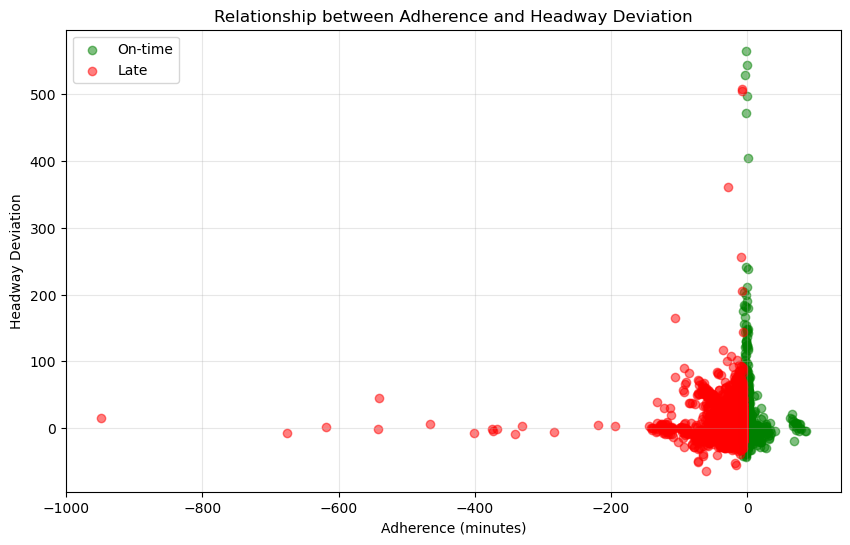

In [24]:
import matplotlib.pyplot as plt
# late vs on time 
late = relate[relate['ADHERENCE'] <= -6]
ontime = relate[relate['ADHERENCE'] >= -6]

plt.figure(figsize=(10, 6))
plt.scatter(ontime['ADHERENCE'], ontime['HDWY_DEV'], alpha=0.5, label='On-time', color='green')
plt.scatter(late['ADHERENCE'], late['HDWY_DEV'], alpha=0.5, label='Late', color='red')
plt.xlabel('Adherence (minutes)')
plt.ylabel('Headway Deviation')
plt.title('Relationship between Adherence and Headway Deviation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Saves the graph as an image do not run unless needed 

In [ ]:
# import matplotlib.pyplot as plt

# late = relate[relate['ADHERENCE'] <= -6]
# ontime = relate[relate['ADHERENCE'] > -6]

# plt.figure(figsize=(10, 6))
# plt.scatter(ontime['ADHERENCE'], ontime['HDWY_DEV'], alpha=0.5, label='On-time', color='green')
# plt.scatter(late['ADHERENCE'], late['HDWY_DEV'], alpha=0.5, label='Late', color='red')
# plt.xlabel('Adherence (minutes)')
# plt.ylabel('Headway Deviation')
# plt.title('Relationship between Adherence and Headway Deviation')
# plt.legend()
# plt.grid(True, alpha=0.3)

# # Save the figure
# plt.savefig('adherence_headway_relationship.png', dpi=300, bbox_inches='tight')
# plt.show()

## 6 How much impact does being late or too spaced out at the first stop have downstream?

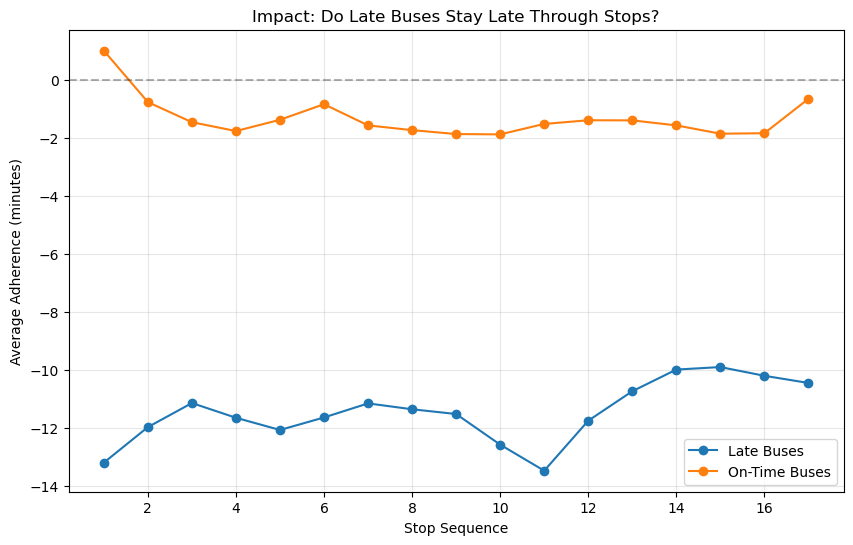

In [40]:
# so its asking how much impact does being late cause at the first stop 
# show a ripple effect over time if the first bus is late at the first stop

relate = relate.sort_values(['TRIP_ID', 'ROUTE_STOP_SEQUENCE'])

# Group by stop sequence and late status
impact = relate.groupby(['ROUTE_STOP_SEQUENCE', 'LATE'])['ADHERENCE'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
for late_status in ['Yes', 'No']:
    data = impact[impact['LATE'] == late_status]
    label = 'Late Buses' if late_status == 'Yes' else 'On-Time Buses'
    plt.plot(data['ROUTE_STOP_SEQUENCE'], data['ADHERENCE'], marker='o', label=label)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.xlabel('Stop Sequence')
plt.ylabel('Average Adherence (minutes)')
plt.title('Impact: Do Late Buses Stay Late Through Stops?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()